In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_train="/content/drive/MyDrive/cse427 project/train.csv"
path_test="/content/drive/MyDrive/cse427 project/test.csv"
train=pd.read_csv(path_train)
test=pd.read_csv(path_test)
train.head(5)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
train.shape

(7613, 5)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [ ]:
train.describe(include='all')

,id,keyword,location,text,target
count,7613.000000,7552,5080,7613,7613.00000
unique,NaN,221,3341,7503,NaN
top,NaN,fatalities,USA,11-Year-Old Boy Charged With Manslaughter of T...,NaN
freq,NaN,45,104,10,NaN
mean,5441.934848,NaN,NaN,NaN,0.42966
std,3137.116090,NaN,NaN,NaN,0.49506
min,1.000000,NaN,NaN,NaN,0.00000
25%,2734.000000,NaN,NaN,NaN,0.00000
50%,5408.000000,NaN,NaN,NaN,0.00000
75%,8146.000000,NaN,NaN,NaN,1.00000


In [ ]:
train.nunique()

,0
id,7613
keyword,221
location,3341
text,7503
target,2


In [ ]:
train.isnull().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


In [ ]:
#separating categorical and numerical features
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['keyword', 'location', 'text']
Numerical Variables:
['id', 'target']


target
0    4342
1    3271
Name: count, dtype: int64


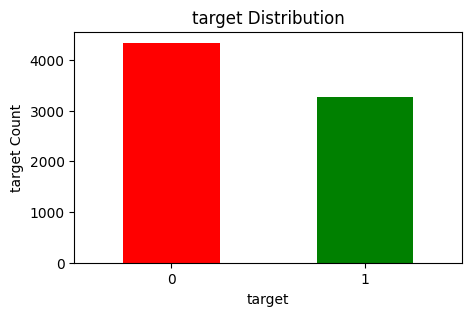

In [ ]:
# Visualize the distribution of the 'target' variable

print(train.value_counts('target'))

plt.figure(figsize=(5, 3))
train['target'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('target Distribution')
plt.xlabel('target')
plt.ylabel('target Count')
plt.xticks(rotation = 0)
plt.show()

keyword distribution

In [ ]:
train['keyword'].value_counts().head(10)

,count
keyword,
fatalities,45
deluge,42
armageddon,42
damage,41
body%20bags,41
harm,41
sinking,41
evacuate,40
outbreak,40


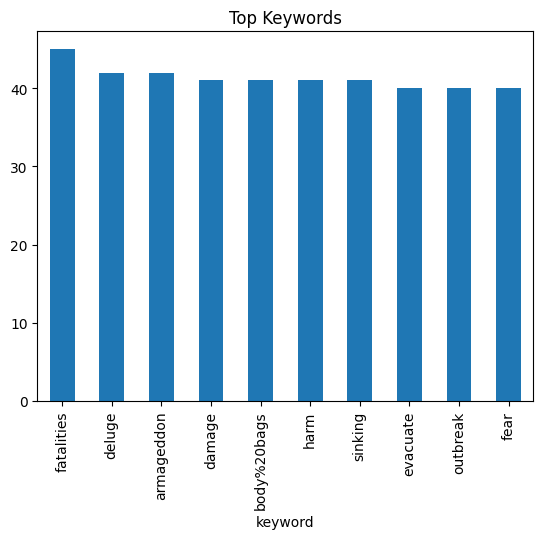

In [ ]:
train['keyword'].value_counts().head(10).plot(kind='bar')
plt.title("Top Keywords")
plt.show()

In [ ]:
#keyword vs disaster
pd.crosstab(train['keyword'], train['target'])

target,0,1
keyword,,
ablaze,23,13
accident,11,24
aftershock,34,0
airplane%20accident,5,30
ambulance,18,20
...,...,...
wounded,11,26
wounds,23,10
wreck,30,7


location distribution

In [ ]:
train['location'].value_counts().head(10)

,count
location,
USA,104
New York,71
United States,50
London,45
Canada,29
Nigeria,28
UK,27
"Los Angeles, CA",26
India,24


<Axes: xlabel='location'>

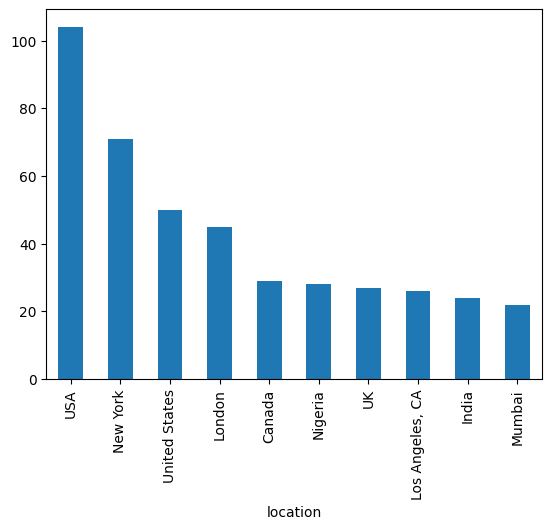

In [ ]:
train['location'].value_counts().head(10).plot(kind='bar')

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
text = " ".join(train['text'])

In [ ]:
tokens = word_tokenize(text.lower())

In [ ]:
from nltk.probability import FreqDist

word_count = FreqDist(tokens)

In [ ]:
word = []
count = []

for tup in word_count.most_common(10):
    word.append(tup[0])
    count.append(tup[1])
print(word)
print(count)

[':', 'http', '#', 'the', '?', '.', '@', 'a', 'in', 'to']
[6706, 4307, 3403, 3233, 3126, 2909, 2759, 2179, 1977, 1945]


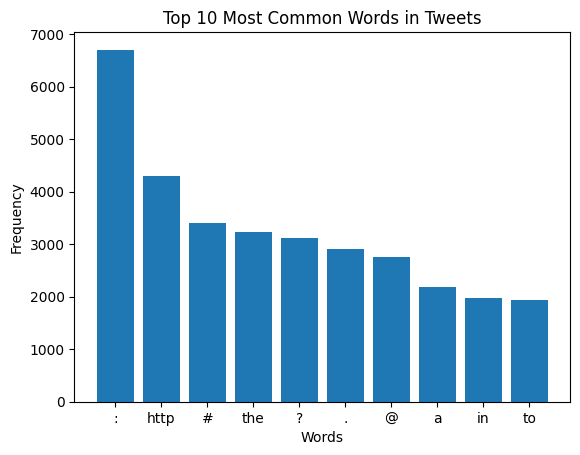

In [ ]:
plt.bar(word, count)
plt.title("Top 10 Most Common Words in Tweets")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

(np.float64(-0.5), np.float64(999.5), np.float64(599.5), np.float64(-0.5))

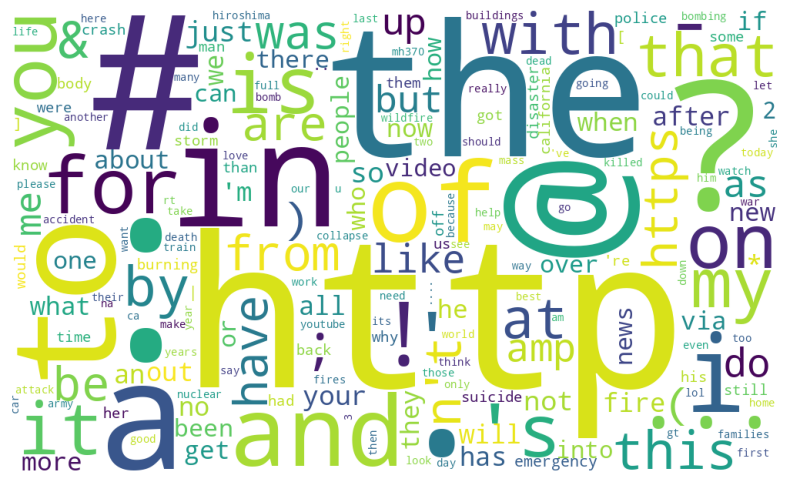

In [ ]:
from wordcloud import WordCloud
unique_words = list(set(tokens))
wc = WordCloud(width = 1000, height = 600, background_color= 'white')
cloud = wc.generate_from_frequencies(word_count)
plt.figure(figsize = (10,6))
plt.imshow(cloud)
plt.axis('off')

Pre-Processing


In [ ]:
def merge_and_drop(df):
    df['keyword'] = df['keyword'].fillna('').str.replace('%20', ' ')
    df['text'] = df['keyword'] + ' ' + df['text']
    df.drop(columns=['id','location', 'keyword'], inplace=True)
    return df

train = merge_and_drop(train)
test  = merge_and_drop(test)

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from bs4 import BeautifulSoup
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))   # define ONCE outside
lemmatizer = WordNetLemmatizer()               # define ONCE outside

def clean_html(text):
    return BeautifulSoup(str(text), 'html.parser').get_text()

def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+|t\.co\S+', '', str(text), flags=re.MULTILINE)

def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', ' ', str(text))

def remove_extra_whitespace(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

def preprocess_text(text):
    text = clean_html(text)
    text = text.lower()
    text = remove_urls(text)
    text = remove_special_chars(text)
    text = remove_extra_whitespace(text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)
train['clean_text'] = train['text'].apply(preprocess_text)
test['clean_text']  = test['text'].apply(preprocess_text)


In [ ]:
tokens = []
for text in train['clean_text']:
    tokens.extend(word_tokenize(text))

In [ ]:
print(tokens)

['deed', 'reason', 'earthquake', 'may', 'allah', 'forgive', 'u', 'forest', 'fire', 'near', 'la', 'ronge', 'sask', 'canada', 'resident', 'asked', 'shelter', 'place', 'notified', 'officer', 'evacuation', 'shelter', 'place', 'order', 'expected', 'people', 'receive', 'wildfire', 'evacuation', 'order', 'california', 'got', 'sent', 'photo', 'ruby', 'alaska', 'smoke', 'wildfire', 'pours', 'school', 'rockyfire', 'update', 'california', 'hwy', 'closed', 'direction', 'due', 'lake', 'county', 'fire', 'cafire', 'wildfire', 'flood', 'disaster', 'heavy', 'rain', 'cause', 'flash', 'flooding', 'street', 'manitou', 'colorado', 'spring', 'area', 'top', 'hill', 'see', 'fire', 'wood', 'emergency', 'evacuation', 'happening', 'building', 'across', 'street', 'afraid', 'tornado', 'coming', 'area', 'three', 'people', 'died', 'heat', 'wave', 'far', 'haha', 'south', 'tampa', 'getting', 'flooded', 'hah', 'wait', 'second', 'live', 'south', 'tampa', 'gon', 'na', 'gon', 'na', 'fvck', 'flooding', 'raining', 'flooding

after preprocessing

In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nAny nulls?")
print(train.isnull().sum())

print("\nSample cleaned texts:")
print(train['text'].head(10))

print("\nLebel distribution:")
print(train['target'].value_counts())

Train shape: (7613, 3)
Test shape: (3263, 2)

Any nulls?
text          0
target        0
clean_text    0
dtype: int64

Sample cleaned texts:
0     Our Deeds are the Reason of this #earthquake ...
1               Forest fire near La Ronge Sask. Canada
2     All residents asked to 'shelter in place' are...
3     13,000 people receive #wildfires evacuation o...
4     Just got sent this photo from Ruby #Alaska as...
5     #RockyFire Update => California Hwy. 20 close...
6     #flood #disaster Heavy rain causes flash floo...
7     I'm on top of the hill and I can see a fire i...
8     There's an emergency evacuation happening now...
9     I'm afraid that the tornado is coming to our ...
Name: text, dtype: object

Lebel distribution:
target
0    4342
1    3271
Name: count, dtype: int64


In [ ]:
from collections import Counter
word_freq = Counter(tokens)
most_common = word_freq.most_common(20)
print(f"\nTop 20 most common words:")
for word, count in most_common:
    print(f"  '{word}': {count}")


Top 20 most common words:
  'fire': 567
  'like': 350
  'emergency': 306
  'u': 265
  'disaster': 265
  'body': 262
  'get': 255
  'building': 246
  'storm': 232
  'new': 228
  'burning': 227
  'via': 220
  'suicide': 219
  'news': 213
  'one': 209
  'people': 201
  'death': 191
  'bomb': 190
  'flood': 186
  'time': 181


dataset splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_full = train['clean_text']
y_full = train['target']
X_test = test['clean_text']

# split training data into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)


print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")


Training set: 6090 samples
Validation set: 1523 samples
Test set: 3263 samples


tf-idf matrix

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)


print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Validation matrix shape: {X_val_tfidf.shape}")
print(f"Test matrix shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")


Done!
Training matrix shape: (6090, 10000)
Validation matrix shape: (1523, 10000)
Test matrix shape: (3263, 10000)
Vocabulary size: 10000


In [ ]:
# see some features
feature_names = tfidf.get_feature_names_out()
print("\nFirst 20 features:")
print(feature_names[:20])

print("\nLast 20 features:")
print(feature_names[-20:])


First 20 features:
['aa' 'aa mgm' 'aaaaaaallll' 'aaaaaaallll even' 'aaaaaand'
 'aaaaaand thunder' 'aaarrrgghhh' 'aace' 'aace org' 'aal' 'aan' 'aan den'
 'aannnnd' 'aannnnd reddit' 'aar' 'aar ambulance' 'ab' 'aba' 'aba woman'
 'abandon']

Last 20 features:
['zone' 'zone coming' 'zone mama' 'zone thank' 'zone turned' 'zone war'
 'zone zone' 'zoom' 'zoom one' 'zouma' 'zouma absolutely'
 'zouma flattened' 'zourryart' 'zourryart forgot' 'zrnf' 'zss' 'zss sw'
 'zumiez' 'zumiez location' 'zurich']


In [ ]:
# see top features by average TF-IDF score
import numpy as np

tfidf_scores = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_indices = tfidf_scores.argsort()[-20:][::-1]

print("\nTop 20 features by average TF-IDF score:")
for idx in top_indices:
    print(f"{feature_names[idx]}: {tfidf_scores[idx]:.4f}")


Top 20 features by average TF-IDF score:
fire: 0.0118
like: 0.0080
emergency: 0.0074
disaster: 0.0067
get: 0.0065
burning: 0.0062
building: 0.0061
storm: 0.0061
death: 0.0059
fatality: 0.0058
body: 0.0058
weapon: 0.0053
new: 0.0052
bomb: 0.0051
via: 0.0051
one: 0.0051
flood: 0.0050
siren: 0.0050
casualty: 0.0048
injury: 0.0048


In [ ]:
# save the vectorizer for later use
import pickle

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("\nTF-IDF vectorizer saved!")


TF-IDF vectorizer saved!


skipgrams

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.9 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

def tokenize_for_w2v(text):
    tokens = text.lower().split()
    tokens = [t for t in tokens if len(t) > 1 and not t.isnumeric()]
    return tokens

sentences = [tokenize_for_w2v(text) for text in X_train]

w2v = Word2Vec(sentences=sentences,
               vector_size=100,
               window=4,
               min_count=2,
               sg=1,# skip-gram
               negative=10, # IMPROVEMENT: stronger negative sampling
               hs=0, # for negative sampling
               epochs=50,
               seed=42 )
print(f"Vocabulary size: {len(w2v.wv)}")



Vocabulary size: 5111


In [ ]:
def show_similar(model, word, topn=5):
    if word in model.wv:
        print(f"\nWords similar to '{word}':")
        print(model.wv.most_similar(word, topn=topn))
    else:
        print(f"\nWord '{word}' not found in vocabulary.")

print("\nTesting Word2Vec embeddings:")
show_similar(w2v, 'love', topn=5)
show_similar(w2v, 'computer', topn=5)



Testing Word2Vec embeddings:

Words similar to 'love':
[('lulgzimbestpicts', 0.6401950120925903), ('truelove', 0.6336230039596558), ('soo', 0.602080762386322), ('lith', 0.583563506603241), ('britishbakeoff', 0.5764738321304321)]

Words similar to 'computer':
[('funtenna', 0.7745371460914612), ('beginner', 0.7161269187927246), ('ergo', 0.6649153828620911), ('tutorial', 0.6467676758766174), ('virus', 0.6234202980995178)]


Model implementation

Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


lr = LogisticRegression(
    max_iter=2000,
    solver='saga',
    class_weight='balanced',
    random_state=42
)

# train
lr.fit(X_train_tfidf, y_train)




LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                   solver='saga')

In [ ]:
# predictions
train_pred = lr.predict(X_train_tfidf)
val_pred = lr.predict(X_val_tfidf)

# evaluation
print("\nTraining Performance:")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("F1 Score:", f1_score(y_train, train_pred, average='macro'))

print("\nValidation Performance:")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("F1 Score:", f1_score(y_val, val_pred, average='macro'))

# classification report
print("\nClassification Report:")
print(classification_report(y_val, val_pred))



Training Performance:
Accuracy: 0.8707717569786535
F1 Score: 0.8677871913436572

Validation Performance:
Accuracy: 0.8030203545633617
F1 Score: 0.7990150019531044

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       869
           1       0.77      0.77      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523



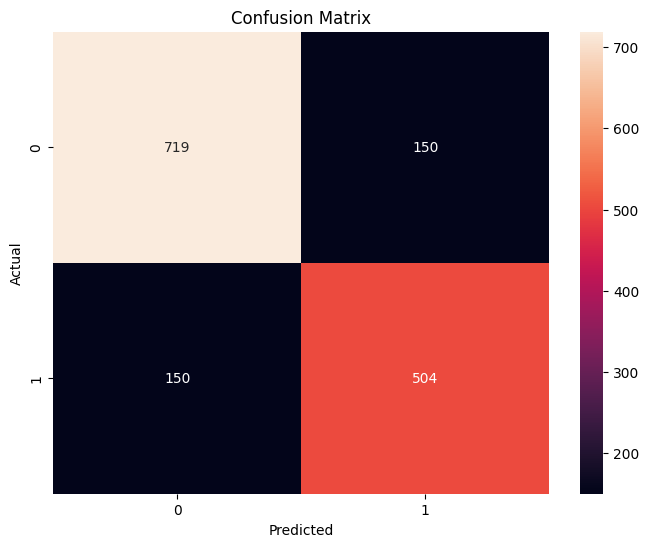

In [ ]:
# confusion matrix
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

naive bayes


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

nb = MultinomialNB()

# train
nb.fit(X_train_tfidf, y_train)

# predictions
train_pred = nb.predict(X_train_tfidf)
val_pred = nb.predict(X_val_tfidf)



In [ ]:
# evaluation
print("\nTraining Performance:")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("F1 Score:", f1_score(y_train, train_pred, average='macro'))

print("\nValidation Performance:")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("F1 Score:", f1_score(y_val, val_pred, average='macro'))

# classification report
print("\nClassification Report:")
print(classification_report(y_val, val_pred))




Training Performance:
Accuracy: 0.8637110016420362
F1 Score: 0.8563790413585854

Validation Performance:
Accuracy: 0.8187787261982928
F1 Score: 0.8084905144606637

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       869
           1       0.87      0.68      0.76       654

    accuracy                           0.82      1523
   macro avg       0.83      0.80      0.81      1523
weighted avg       0.83      0.82      0.81      1523



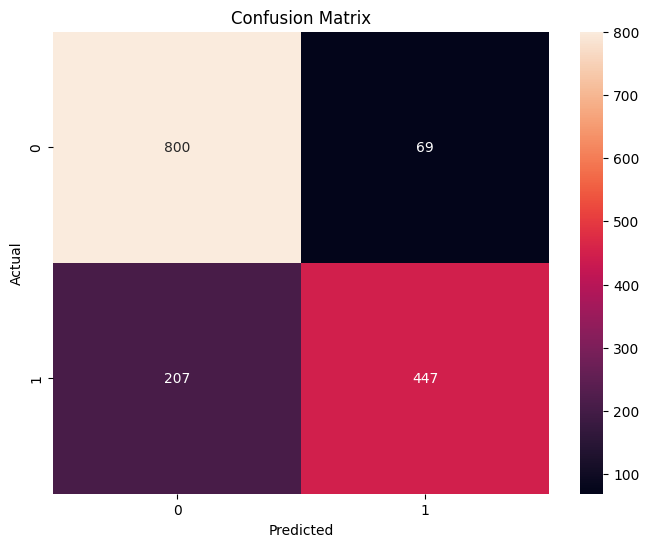

In [ ]:
# confusion matrix
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# simple and practical model
rf = RandomForestClassifier(
    n_estimators=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# train
rf.fit(X_train_tfidf, y_train)

# predictions
train_pred = rf.predict(X_train_tfidf)
val_pred = rf.predict(X_val_tfidf)


In [ ]:
# evaluation
print("\nTraining Performance:")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("F1 Score:", f1_score(y_train, train_pred, average='macro'))

print("\nValidation Performance:")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("F1 Score:", f1_score(y_val, val_pred, average='macro'))

# classification report
print("\nClassification Report:")
print(classification_report(y_val, val_pred))




Training Performance:
Accuracy: 0.9866995073891626
F1 Score: 0.9864072430114301

Validation Performance:
Accuracy: 0.7971109652002626
F1 Score: 0.787368637927973

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.83       869
           1       0.82      0.68      0.74       654

    accuracy                           0.80      1523
   macro avg       0.80      0.78      0.79      1523
weighted avg       0.80      0.80      0.79      1523



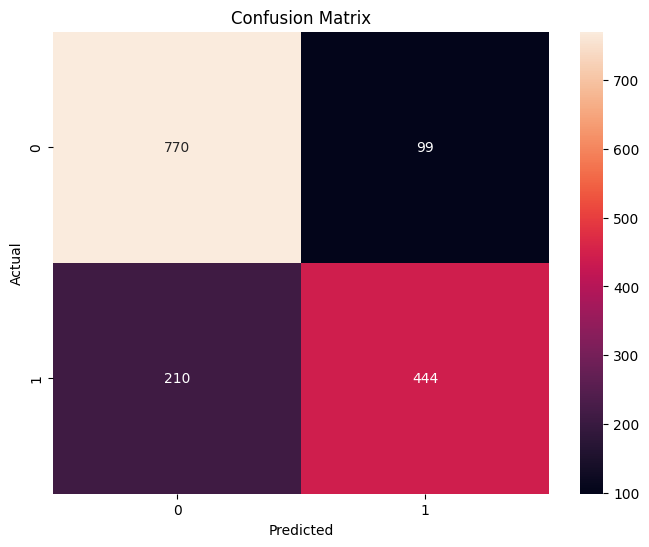

In [ ]:
# confusion matrix
cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Simple RNN

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#conver text to seq
num_words = 5000
max_length = 50

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')


#EM
embedding_dim = w2v.vector_size
vocab_size = min(num_words, len(tokenizer.word_index) + 1)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v.wv:
            embedding_matrix[i] = w2v.wv[word]

#Model
simple_rnn_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True
    ),

    SimpleRNN(64, return_sequences=False),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

simple_rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

simple_rnn_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = simple_rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 500,000 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6770 - loss: 0.6120 - val_accuracy: 0.7157 - val_loss: 0.5815
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7414 - loss: 0.5653 - val_accuracy: 0.7518 - val_loss: 0.5514
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7826 - loss: 0.5111 - val_accuracy: 0.7932 - val_loss: 0.4865
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8184 - loss: 0.4602 - val_accuracy: 0.7919 - val_loss: 0.4784
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8402 - loss: 0.4216 - val_accuracy: 0.8043 - val_loss: 0.4853
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8181 - loss: 0.4573 - val_accuracy: 0.7853 - val_loss: 0.4908
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8488 - loss: 0.3986 - val_accuracy: 0.7978 - val_loss: 0.5000


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

train_prob = simple_rnn_model.predict(X_train_pad)
train_pred = (train_prob > 0.5).astype(int)
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Training F1 Score:", f1_score(y_train, train_pred, average='macro'))
print("\nTraining Classification Report:")
print(classification_report(y_train, train_pred))


val_prob = simple_rnn_model.predict(X_val_pad)
val_pred = (val_prob > 0.5).astype(int)
print("\nValidation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation F1 Score:", f1_score(y_val, val_pred, average='macro'))
print("\nValidation Classification Report:")
print(classification_report(y_val, val_pred))

191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Training Accuracy: 0.8435139573070608
Training F1 Score: 0.8350567188360727

Training Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      3473
           1       0.90      0.72      0.80      2617

    accuracy                           0.84      6090
   macro avg       0.86      0.83      0.84      6090
weighted avg       0.85      0.84      0.84      6090

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Validation Accuracy: 0.7918581746552856
Validation F1 Score: 0.7770909082514377

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       869
           1       0.85      0.62      0.72       654

    accuracy                           0.79      1523
   macro avg       0.81      0.77      0.78      1523
weighted avg       0.80      0.79      0.79      1523



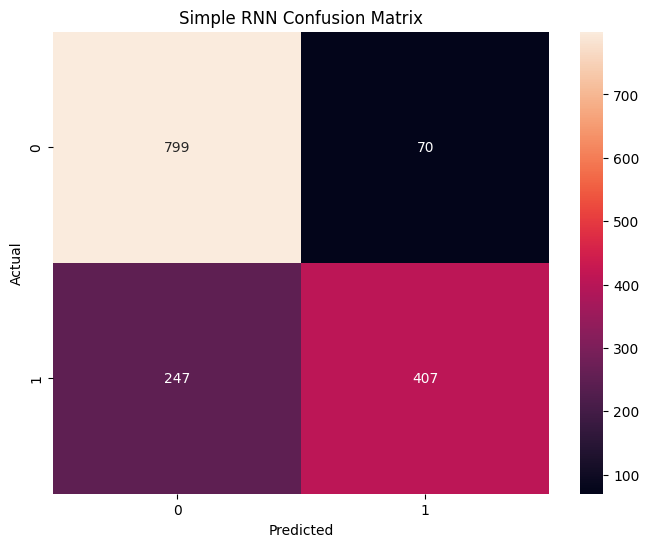

In [ ]:
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Bi-Directional RNN

In [ ]:
from tensorflow.keras.layers import Bidirectional
bi_rnn_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True
    ),

    Bidirectional(SimpleRNN(64, return_sequences=False)),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

bi_rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

bi_rnn_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bi_rnn = bi_rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 500,000 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7084 - loss: 0.5876 - val_accuracy: 0.7663 - val_loss: 0.5030
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.7821 - loss: 0.4880 - val_accuracy: 0.7787 - val_loss: 0.4816
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8192 - loss: 0.4173 - val_accuracy: 0.8089 - val_loss: 0.4500
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8529 - loss: 0.3559 - val_accuracy: 0.7984 - val_loss: 0.4738
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.8829 - loss: 0.2927 - val_accuracy: 0.7971 - val_loss: 0.5040
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9118 - loss: 0.2307 - val_accuracy: 0.7833 - val_loss: 0.5591


In [ ]:
#Evaluate
bi_train_prob = bi_rnn_model.predict(X_train_pad)
bi_train_pred = (bi_train_prob > 0.5).astype(int)

print("Training Accuracy:", accuracy_score(y_train, bi_train_pred))
print("Training F1 Score:", f1_score(y_train, bi_train_pred, average='macro'))


bi_val_prob = bi_rnn_model.predict(X_val_pad)
bi_val_pred = (bi_val_prob > 0.5).astype(int)

print("\nValidation Accuracy:", accuracy_score(y_val, bi_val_pred))
print("Validation F1 Score:", f1_score(y_val, bi_val_pred, average='macro'))

print("\nValidation Classification Report:")
print(classification_report(y_val, bi_val_pred))

191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Training Accuracy: 0.8704433497536945
Training F1 Score: 0.8662606565750313
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Validation Accuracy: 0.8089297439264609
Validation F1 Score: 0.802245653864637

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       869
           1       0.81      0.73      0.77       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.80      1523
weighted avg       0.81      0.81      0.81      1523



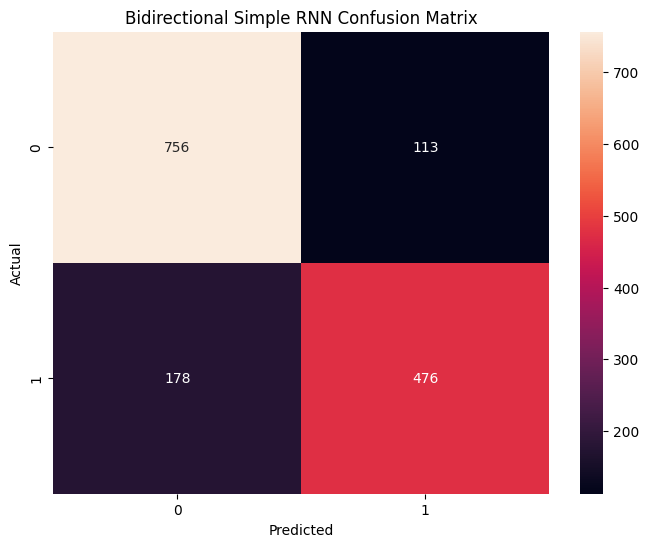

In [ ]:
cm = confusion_matrix(y_val, bi_val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Bidirectional Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

LSTM

In [ ]:
from tensorflow.keras.layers import LSTM
lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True
    ),

    LSTM(64, return_sequences=False),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 500,000 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.5828 - loss: 0.6750 - val_accuracy: 0.6999 - val_loss: 0.5957
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.7775 - loss: 0.5023 - val_accuracy: 0.8050 - val_loss: 0.4544
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8271 - loss: 0.4140 - val_accuracy: 0.8181 - val_loss: 0.4221
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8514 - loss: 0.3686 - val_accuracy: 0.8070 - val_loss: 0.4386
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.8750 - loss: 0.3198 - val_accuracy: 0.8135 - val_loss: 0.4327
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8924 - loss: 0.2868 - val_accuracy: 0.7984 - val_loss: 0.5444


In [ ]:
#Evaluate
lstm_train_prob = lstm_model.predict(X_train_pad)
lstm_train_pred = (lstm_train_prob > 0.5).astype(int)
print("Training Accuracy:", accuracy_score(y_train, lstm_train_pred))
print("Training F1 Score:", f1_score(y_train, lstm_train_pred, average='macro'))
print("\nTraining Classification Report:")
print(classification_report(y_train, lstm_train_pred))


# -------- VALIDATION PERFORMANCE --------
lstm_val_prob = lstm_model.predict(X_val_pad)
lstm_val_pred = (lstm_val_prob > 0.5).astype(int)
print("\nValidation Accuracy:", accuracy_score(y_val, lstm_val_pred))
print("Validation F1 Score:", f1_score(y_val, lstm_val_pred, average='macro'))
print("\nValidation Classification Report:")
print(classification_report(y_val, lstm_val_pred))

191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
Training Accuracy: 0.8592775041050903
Training F1 Score: 0.8543786230576429

Training Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      3473
           1       0.87      0.79      0.83      2617

    accuracy                           0.86      6090
   macro avg       0.86      0.85      0.85      6090
weighted avg       0.86      0.86      0.86      6090

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

Validation Accuracy: 0.8181221273801708
Validation F1 Score: 0.8107802141169727

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       869
           1       0.83      0.72      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



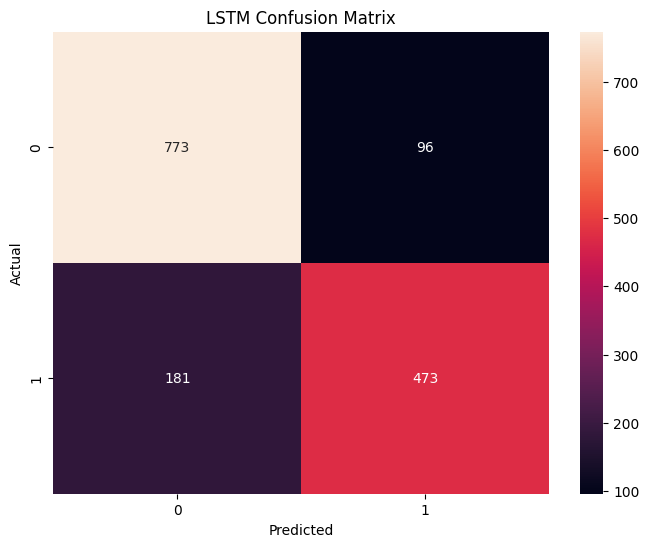

In [ ]:
cm = confusion_matrix(y_val, lstm_val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Bi-Directional LSTM

In [ ]:
bi_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True
    ),

    Bidirectional(LSTM(64, return_sequences=False)),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

bi_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

bi_lstm_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bi_lstm = bi_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 500,000 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.7471 - loss: 0.5304 - val_accuracy: 0.7951 - val_loss: 0.4473
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.8148 - loss: 0.4235 - val_accuracy: 0.8122 - val_loss: 0.4238
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.8417 - loss: 0.3779 - val_accuracy: 0.8188 - val_loss: 0.4267
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.8647 - loss: 0.3305 - val_accuracy: 0.8148 - val_loss: 0.4276
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.8903 - loss: 0.2796 - val_accuracy: 0.8188 - val_loss: 0.4728


In [ ]:
#Evaluate
# -------- TRAINING PERFORMANCE --------
bi_lstm_train_prob = bi_lstm_model.predict(X_train_pad)
bi_lstm_train_pred = (bi_lstm_train_prob > 0.5).astype(int)

print("Training Accuracy:", accuracy_score(y_train, bi_lstm_train_pred))
print("Training F1 Score:", f1_score(y_train, bi_lstm_train_pred, average='macro'))

print("\nTraining Classification Report:")
print(classification_report(y_train, bi_lstm_train_pred))


# -------- VALIDATION PERFORMANCE --------
bi_lstm_val_prob = bi_lstm_model.predict(X_val_pad)
bi_lstm_val_pred = (bi_lstm_val_prob > 0.5).astype(int)

print("\nValidation Accuracy:", accuracy_score(y_val, bi_lstm_val_pred))
print("Validation F1 Score:", f1_score(y_val, bi_lstm_val_pred, average='macro'))

print("\nValidation Classification Report:")
print(classification_report(y_val, bi_lstm_val_pred))

191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step
Training Accuracy: 0.8426929392446634
Training F1 Score: 0.8320360038582473

Training Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      3473
           1       0.93      0.69      0.79      2617

    accuracy                           0.84      6090
   macro avg       0.87      0.82      0.83      6090
weighted avg       0.86      0.84      0.84      6090

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

Validation Accuracy: 0.8122127380170716
Validation F1 Score: 0.7983741357793817

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.94      0.85       869
           1       0.89      0.64      0.75       654

    accuracy                           0.81      1523
   macro avg       0.83      0.79      0.80      1523
weighted avg       0.83      0.81      0.81      1523



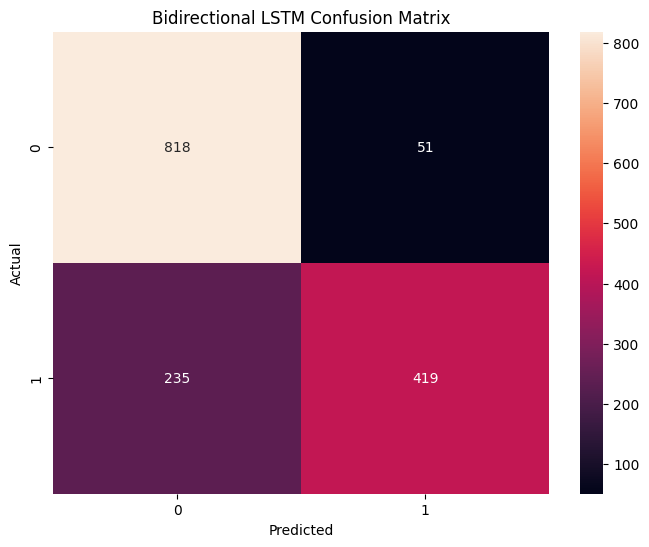

In [ ]:
cm = confusion_matrix(y_val, bi_lstm_val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Bidirectional LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

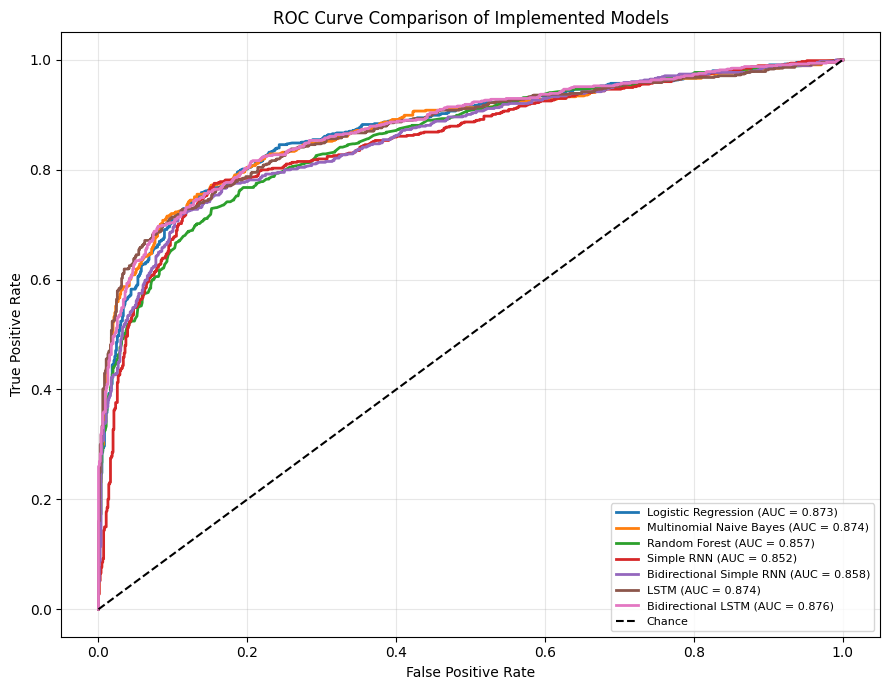

In [ ]:
# ROC Curve Comparison


import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# Recreate validation split if y_val is missing
if "y_val" not in globals():
    X_full = train["clean_text"]
    y_full = train["target"]

    X_train, X_val, y_train, y_val = train_test_split(
        X_full,
        y_full,
        test_size=0.2,
        random_state=42,
        stratify=y_full
    )

# Make y_val 1D
y_val_array = np.array(y_val).ravel()

# Validation probability scores
lr_scores = lr.predict_proba(X_val_tfidf)[:, 1]
nb_scores = nb.predict_proba(X_val_tfidf)[:, 1]
rf_scores = rf.predict_proba(X_val_tfidf)[:, 1]

simple_rnn_scores = simple_rnn_model.predict(X_val_pad, verbose=0).ravel()
bi_rnn_scores = bi_rnn_model.predict(X_val_pad, verbose=0).ravel()
lstm_scores = lstm_model.predict(X_val_pad, verbose=0).ravel()
bi_lstm_scores = bi_lstm_model.predict(X_val_pad, verbose=0).ravel()

model_scores = {
    "Logistic Regression": lr_scores,
    "Multinomial Naive Bayes": nb_scores,
    "Random Forest": rf_scores,
    "Simple RNN": simple_rnn_scores,
    "Bidirectional Simple RNN": bi_rnn_scores,
    "LSTM": lstm_scores,
    "Bidirectional LSTM": bi_lstm_scores
}

plt.figure(figsize=(9, 7))

for model_name, scores in model_scores.items():
    fpr, tpr, thresholds = roc_curve(y_val_array, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Implemented Models")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()